In [ ]:
from pathlib import Path
import accelforge as af


EXAMPLE_FILE = "archs/both.yaml"
traditional_accelerator_path = "archs/traditional.yaml"
pim_accelerator_path = "archs/longsight.yaml"
mapping_file = "map.yaml"
workload_file = "prob.yaml"


traditional_name = Path(traditional_accelerator_path).stem
pim_name = Path(pim_accelerator_path).stem

yaml_files = [EXAMPLE_FILE, mapping_file, workload_file]
spec = af.Spec.from_yaml(
    yaml_files,
    traditional_accelerator_path=traditional_name,
    pim_accelerator_path=pim_name,
 )

print("Loaded combined spec from example.yaml")
print(f"traditional_accelerator_path={traditional_accelerator_path}")
print(f"pim_accelerator_path={pim_accelerator_path}")
print(f"mapping_file={mapping_file}")

Loaded combined spec from example.yaml
traditional_accelerator_path=archs/traditional.yaml
pim_accelerator_path=archs/longsight.yaml
mapping_file=map.yaml


In [25]:
import accelforge as af

BENCHMARK_CASES = [
    {
        "name": "dense_attention",
        "arch": "archs/longsight.yaml",
        "mapping": "map_dense.yaml",
        "workload": "prob_dense.yaml",
    },
    {
        "name": "sparse_attention",
        "arch": "archs/longsight.yaml",
        "mapping": "map_sparse.yaml",
        "workload": "prob_sparse.yaml",
    },
]

def run_benchmarks(cases):
    rows = []
    for case in cases:
        yaml_files = [case["arch"], case["mapping"], case["workload"]]
        spec = af.Spec.from_yaml(yaml_files)
        mappings = spec.map_workload_to_arch(
            print_progress=False,
            print_number_of_pmappings=False,
        )

        energy_pj = sum(mappings.energy(per_component=True).values()) * 1e12
        latency = mappings.latency()

        actions = mappings.actions(per_component=True)
        total_compute_ops = sum(
            count for (component, action), count in actions.items() if action == "compute"
        )
        energy_per_op = energy_pj / total_compute_ops if total_compute_ops else 0.0

        row = {
            "workload": case["name"],
            "latency_cycles": latency,
            "total_energy_pj": energy_pj,
            "total_compute_ops": total_compute_ops,
            "energy_per_op_pj": energy_per_op,
        }
        rows.append(row)

        print(
            f"{row['workload']}: latency={row['latency_cycles']:.6f} cycles | "
            f"energy={row['total_energy_pj']:.2f} pJ | "
            f"ops={int(row['total_compute_ops'])} | "
            f"pJ/op={row['energy_per_op_pj']:.6f}"
        )

    return rows

benchmark_results = run_benchmarks(BENCHMARK_CASES)
benchmark_results

EvaluationError: EvaluationError in Einsum DenseQKT arch.Bank_Storage.tensors.keep.keep: name 'QuerySign' is not defined. Set expression: "QuerySign | KeySign | Concordance | FilteredKey | SimScore". Symbol table:
	All: InvertibleSet(frozenset({'Query', 'DenseScore', 'DenseKey'}))
	Tensors: InvertibleSet(frozenset({'Query', 'DenseScore', 'DenseKey'}))
	Nothing: InvertibleSet(frozenset())
	Inputs: InvertibleSet(frozenset({'Query', 'DenseKey'}))
	Outputs: InvertibleSet(frozenset({'DenseScore'}))
	Intermediates: InvertibleSet(frozenset({'DenseScore'}))
	Shared: InvertibleSet(frozenset({'DenseScore'}))
	Persistent: InvertibleSet(frozenset())
	DenseKey: InvertibleSet(frozenset({'DenseKey'}))
	DenseScore: InvertibleSet(frozenset({'DenseScore'}))
	Query: InvertibleSet(frozenset({'Query'}))
	d: InvertibleSet(frozenset({'d'}))
	h: InvertibleSet(frozenset({'h'}))
	w: InvertibleSet(frozenset({'w'}))
	DenseOutput: InvertibleSet(frozenset())
	DenseValue: InvertibleSet(frozenset())
	Above: Invertibl

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


K_s=256
  traditional_arch: latency=0.001533 cycles, energy=968231526.40 pJ
  longsight_arch: latency=0.033294 cycles, energy=969464545.28 pJ
  delta (longsight - traditional): latency=0.031761 cycles (+2071.71%), energy=1233018.88 pJ (+0.13%)


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


K_s=512
  traditional_arch: latency=0.001556 cycles, energy=993867571.20 pJ
  longsight_arch: latency=0.062632 cycles, energy=996917575.68 pJ
  delta (longsight - traditional): latency=0.061076 cycles (+3923.97%), energy=3050004.48 pJ (+0.31%)


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


K_s=1024
  traditional_arch: latency=0.001603 cycles, energy=1045139660.80 pJ
  longsight_arch: latency=0.121309 cycles, energy=1051823636.48 pJ
  delta (longsight - traditional): latency=0.119706 cycles (+7466.24%), energy=6683975.68 pJ (+0.64%)
K_s=2048
  traditional_arch: latency=0.001697 cycles, energy=1147683840.00 pJ
  longsight_arch: latency=0.238662 cycles, energy=1161635758.08 pJ
  delta (longsight - traditional): latency=0.236965 cycles (+13964.48%), energy=13951918.08 pJ (+1.22%)


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


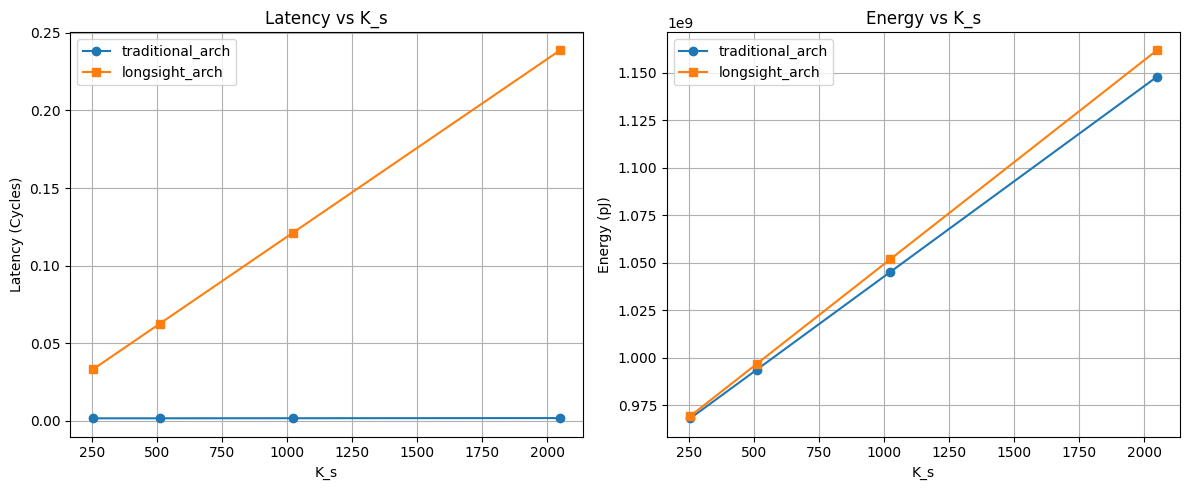

{'arch_rows': [{'name': 'traditional_arch',
   'ks': 256,
   'latency': 0.001533074420876801,
   'energy_pj': 968231526.4000002},
  {'name': 'longsight_arch',
   'ks': 256,
   'latency': 0.0332939438521862,
   'energy_pj': 969464545.2800001},
  {'name': 'traditional_arch',
   'ks': 512,
   'latency': 0.0015564800705760717,
   'energy_pj': 993867571.2000003},
  {'name': 'longsight_arch',
   'ks': 512,
   'latency': 0.06263226270675659,
   'energy_pj': 996917575.6800002},
  {'name': 'traditional_arch',
   'ks': 1024,
   'latency': 0.001603291486389935,
   'energy_pj': 1045139660.7999998},
  {'name': 'longsight_arch',
   'ks': 1024,
   'latency': 0.12130889296531677,
   'energy_pj': 1051823636.4800001},
  {'name': 'traditional_arch',
   'ks': 2048,
   'latency': 0.0016969144344329834,
   'energy_pj': 1147683840.0},
  {'name': 'longsight_arch',
   'ks': 2048,
   'latency': 0.23866216838359833,
   'energy_pj': 1161635758.0800002}],
 'delta_rows': [{'ks': 256,
   'traditional_latency': 0.001

In [28]:
import accelforge as af
import matplotlib.pyplot as plt

SPARSE_COMPARE_KS_VALUES = [256, 512, 1024, 2048]
SPARSE_ARCH_COMPARE_CASES = [
    {
        "name": "traditional_arch",
        "arch": "archs/traditional.yaml",
        "mapping": "map_traditional_sparse.yaml",
        "workload": "prob.yaml",
    },
    {
        "name": "longsight_arch",
        "arch": "archs/longsight.yaml",
        "mapping": "map.yaml",
        "workload": "prob.yaml",
    },
]

def run_sparse_arch_case(case, ks_value):
    yaml_files = [case["arch"], case["mapping"], case["workload"]]
    spec = af.Spec.from_yaml(yaml_files)
    spec.workload.rank_sizes["K_s"] = ks_value
    mappings = spec.map_workload_to_arch(
        print_progress=False,
        print_number_of_pmappings=False,
    )

    try:
        latency = mappings.cycles()
    except AttributeError:
        latency = mappings.latency()

    energy_pj = sum(mappings.energy(per_component=True).values()) * 1e12
    return {
        "name": case["name"],
        "ks": ks_value,
        "latency": float(latency),
        "energy_pj": float(energy_pj),
    }

arch_rows = []
delta_rows = []
ks_axis = []
traditional_latency = []
longsight_latency = []
traditional_energy = []
longsight_energy = []

for ks in SPARSE_COMPARE_KS_VALUES:
    per_case = [run_sparse_arch_case(case, ks) for case in SPARSE_ARCH_COMPARE_CASES]
    traditional = next(r for r in per_case if r["name"] == "traditional_arch")
    longsight = next(r for r in per_case if r["name"] == "longsight_arch")

    arch_rows.extend(per_case)
    ks_axis.append(ks)
    traditional_latency.append(traditional["latency"])
    longsight_latency.append(longsight["latency"])
    traditional_energy.append(traditional["energy_pj"])
    longsight_energy.append(longsight["energy_pj"])

    delta_latency = longsight["latency"] - traditional["latency"]
    delta_energy = longsight["energy_pj"] - traditional["energy_pj"]
    latency_pct = (delta_latency / traditional["latency"] * 100.0) if traditional["latency"] else float("nan")
    energy_pct = (delta_energy / traditional["energy_pj"] * 100.0) if traditional["energy_pj"] else float("nan")

    delta_row = {
        "ks": ks,
        "traditional_latency": traditional["latency"],
        "longsight_latency": longsight["latency"],
        "delta_latency": delta_latency,
        "latency_pct": latency_pct,
        "traditional_energy_pj": traditional["energy_pj"],
        "longsight_energy_pj": longsight["energy_pj"],
        "delta_energy_pj": delta_energy,
        "energy_pct": energy_pct,
    }
    delta_rows.append(delta_row)

    print(f"K_s={ks}")
    print(
        f"  traditional_arch: latency={traditional['latency']:.6f} cycles, "
        f"energy={traditional['energy_pj']:.2f} pJ"
    )
    print(
        f"  longsight_arch: latency={longsight['latency']:.6f} cycles, "
        f"energy={longsight['energy_pj']:.2f} pJ"
    )
    print(
        f"  delta (longsight - traditional): "
        f"latency={delta_latency:.6f} cycles ({latency_pct:+.2f}%), "
        f"energy={delta_energy:.2f} pJ ({energy_pct:+.2f}%)"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(ks_axis, traditional_latency, marker="o", label="traditional_arch")
ax1.plot(ks_axis, longsight_latency, marker="s", label="longsight_arch")
ax1.set_title("Latency vs K_s")
ax1.set_xlabel("K_s")
ax1.set_ylabel("Latency (Cycles)")
ax1.grid(True)
ax1.legend()

ax2.plot(ks_axis, traditional_energy, marker="o", label="traditional_arch")
ax2.plot(ks_axis, longsight_energy, marker="s", label="longsight_arch")
ax2.set_title("Energy vs K_s")
ax2.set_xlabel("K_s")
ax2.set_ylabel("Energy (pJ)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

sparse_ks_comparison = {
    "arch_rows": arch_rows,
    "delta_rows": delta_rows,
}
sparse_ks_comparison

Starting Sweep (In-Memory Implementation)...
Testing 5x ratio (K_s=26214)... Done. Energy: 3753158932.48 pJ | Total compute: 0.069083 pJ/op (5468928 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (3355392 ops)
Testing 10x ratio (K_s=13107)... 

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Done. Energy: 2347585223.68 pJ | Total compute: 0.077528 pJ/op (3791232 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (1677696 ops)
Testing 20x ratio (K_s=6553)... 

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Done. Energy: 1644744750.08 pJ | Total compute: 0.085351 pJ/op (2952320 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (838784 ops)
Testing 40x ratio (K_s=3276)... 

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Done. Energy: 1293324513.28 pJ | Total compute: 0.091205 pJ/op (2532864 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (419328 ops)


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


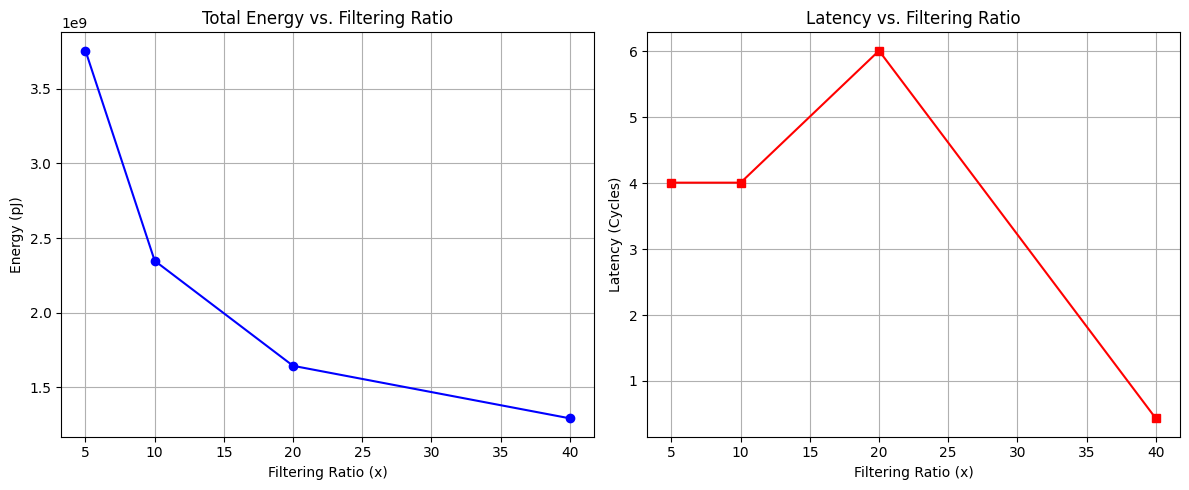

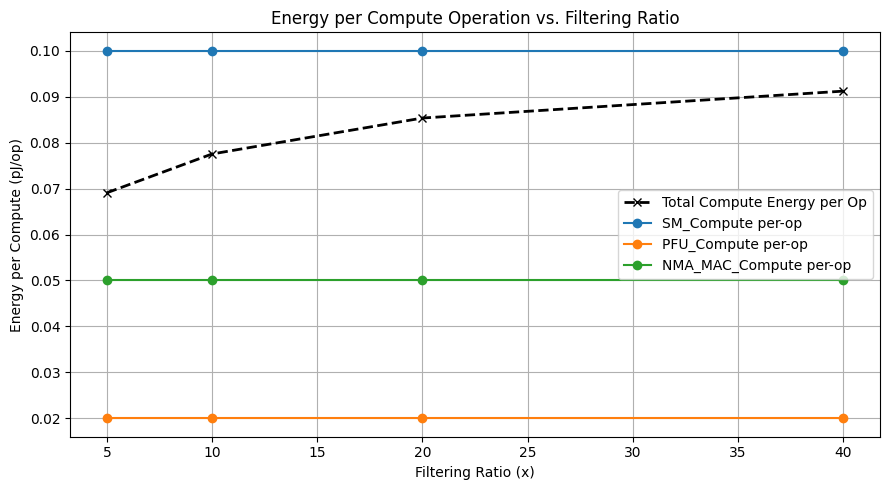

In [24]:
import matplotlib.pyplot as plt
import accelforge as af

# Configuration
PROB_FILE = 'prob.yaml'
ARCH_FILES = ["archs/longsight.yaml", "map.yaml"]
TOTAL_KEYS = 131072

# Compute units to track for normalized compute energy
COMPUTE_UNITS = ["SM_Compute", "PFU_Compute", "NMA_MAC_Compute"]


def main():
    yaml_files = ARCH_FILES + [PROB_FILE]
    spec = af.Spec.from_yaml(yaml_files)

    filtering_ratios = [5, 10, 20, 40]
    energies = []
    latencies = []

    # pJ per compute-op for each compute unit
    compute_energy_per_op_history = {unit: [] for unit in COMPUTE_UNITS}
    # pJ per compute-op aggregated across all compute units
    total_energy_per_op_history = []

    print("Starting Sweep (In-Memory Implementation)...")

    for ratio in filtering_ratios:
        new_ks = int(TOTAL_KEYS / ratio)
        spec.workload.rank_sizes['K_s'] = new_ks

        print(f"Testing {ratio}x ratio (K_s={new_ks})...", end=" ", flush=True)

        try:
            mappings = spec.map_workload_to_arch(
                print_progress=False,
                print_number_of_pmappings=False
            )

            component_energy_j = mappings.energy(per_component=True)
            action_counts = mappings.actions(per_component=True)
            energy_pj = sum(component_energy_j.values()) * 1e12

            unit_ops = {}
            unit_energy_per_op = {}
            for unit in COMPUTE_UNITS:
                ops = action_counts.get((unit, 'compute'), 0.0)
                unit_ops[unit] = ops

                unit_energy_pj = component_energy_j.get(unit, 0.0) * 1e12
                unit_epop = unit_energy_pj / ops if ops else 0.0
                unit_energy_per_op[unit] = unit_epop
                compute_energy_per_op_history[unit].append(unit_epop)

            total_compute_ops = sum(unit_ops.values())
            total_compute_energy_pj = sum(component_energy_j.get(unit, 0.0) for unit in COMPUTE_UNITS) * 1e12
            total_epop = total_compute_energy_pj / total_compute_ops if total_compute_ops else 0.0
            total_energy_per_op_history.append(total_epop)

            try:
                cycles = mappings.cycles()
            except AttributeError:
                cycles = mappings.latency()

            energies.append(energy_pj)
            latencies.append(cycles)

            per_unit = ", ".join(
                f"{u}={unit_energy_per_op[u]:.6f} pJ/op ({int(unit_ops[u])} ops)"
                for u in COMPUTE_UNITS
            )
            print(
                f"Done. Energy: {energy_pj:.2f} pJ | "
                f"Total compute: {total_epop:.6f} pJ/op ({int(total_compute_ops)} ops) | {per_unit}"
            )

        except Exception as e:
            print(f"FAILED! Error: {e}")
            break

    # 5. Visualize the results
    if energies:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.plot(filtering_ratios[:len(energies)], energies, marker='o', color='blue')
        ax1.set_title('Total Energy vs. Filtering Ratio')
        ax1.set_xlabel('Filtering Ratio (x)')
        ax1.set_ylabel('Energy (pJ)')
        ax1.grid(True)

        ax2.plot(filtering_ratios[:len(latencies)], latencies, marker='s', color='red')
        ax2.set_title('Latency vs. Filtering Ratio')
        ax2.set_xlabel('Filtering Ratio (x)')
        ax2.set_ylabel('Latency (Cycles)')
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        fig2, ax3 = plt.subplots(figsize=(9, 5))
        ax3.plot(
            filtering_ratios[:len(total_energy_per_op_history)],
            total_energy_per_op_history,
            marker='x',
            linestyle='--',
            color='black',
            linewidth=2,
            label='Total Compute Energy per Op'
        )

        for unit in COMPUTE_UNITS:
            ax3.plot(
                filtering_ratios[:len(compute_energy_per_op_history[unit])],
                compute_energy_per_op_history[unit],
                marker='o',
                label=f'{unit} per-op'
            )

        ax3.set_title('Energy per Compute Operation vs. Filtering Ratio')
        ax3.set_xlabel('Filtering Ratio (x)')
        ax3.set_ylabel('Energy per Compute (pJ/op)')
        ax3.grid(True)
        ax3.legend()

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

In [8]:
!which timeloop-model
!which accelforge

In [9]:
!find / -name "timeloop-model" -type f 2>/dev/null
!find / -name "accelforge" -type f 2>/dev/null